In [4]:
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel



### Graph

In [6]:
class greetclass(BaseModel):
    message:str

In [27]:
graph1 = StateGraph(greetclass)

### Node,Edge

In [26]:
# node is nothing but a python function.

def greetfun(state):
    state.message = f"{state.message}"
    return state

def upperfun(state):
    state.message = f"{state.message.upper()}"
    return state


In [28]:
graph1.add_node("greetfun", greetfun)
graph1.add_node("upperfun", upperfun)


In [29]:
graph1.add_edge(START, "greetfun")
graph1.add_edge("greetfun", "upperfun")
graph1.add_edge("upperfun", END)

In [32]:
app1 = graph1.compile()

In [31]:
res = app1.invoke({"message":"good noon!!"})

res

{'message': 'GOOD NOON!!'}

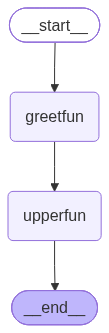

In [ ]:
from IPython.display import Image
Image(app1.get_graph().draw_mermaid_png())  ## we will get this image using above also. graph.compile()